# 문제 2 — 회전 행렬 구현과 합성 순서 검증

축별 회전 행렬 `rot_x`, `rot_y`, `rot_z` 를 직접 구현하고,
회전이 갖는 성질들을 행렬과 그림 양쪽으로 확인합니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 2-1 | 축별 회전 행렬을 만들고 `rot_z(90도)` 가 (1,0,0) 을 (0,1,0) 으로 보내는지 확인 | `rot_x`, `rot_y`, `rot_z` |
| 2-2 | 세 축 회전을 **Matplotlib 3D 로 그려** 회전축 성분이 보존됨을 눈으로 확인 | — |
| 2-3 | **합성 순서가 다르면 결과가 달라짐**을 행렬과 **나란히 그린 3D 그림**으로 비교 | — |
| 2-4 | 세 회전 행렬의 행렬식과 반사 행렬 `diag(1,1,-1)` 의 행렬식을 비교하고 **왜 1 이어야 하는지** 설명 | (문제 1 의 `det`) |
| 2-5 | 문제 1 의 `skew` 로 **로드리게스 공식**을 구현하고 `rot_z` 와 일치하는지 검증 | `rodrigues` |

> 각도는 **라디안**으로 받습니다. 도 단위는 `np.deg2rad` 로 바꿔 넣으세요.
> 순서 의존성 비교 그림은 **반드시 포함**되어야 합니다.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rodrigues, rot_x, rot_y, rot_z, rodrigues_matrix
from src.vectors import det, skew , norm , cross       # 문제 1 에서 만든 함수를 재사용

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 한글 라벨이 깨지지 않도록 폰트 지정 (Windows 기준, 없으면 기본 폰트로 fallback)
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# --- 그림 헬퍼 (그대로 쓰면 됩니다) -----------------------------------------

def draw_frame(ax, R=np.eye(3), origin=(0, 0, 0), scale=1.0, alpha=1.0, labels=None):
    """회전 행렬 R 의 세 열을 x(빨강)·y(초록)·z(파랑) 축으로 그린다."""
    origin = np.asarray(origin, dtype=float)
    colors = ["r", "g", "b"]
    names = labels if labels else ["x", "y", "z"]
    for i in range(3):
        v = R[:, i] * scale
        ax.quiver(*origin, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.15)
        ax.text(*(origin + v * 1.12), names[i], color=colors[i], fontsize=9)


def setup_axes(ax, title, lim=1.3):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 2-1. 축별 회전 행렬과 `rot_z(90도)` 검증

오른손 좌표계에서 각 축 회전 행렬은 다음과 같습니다.

$$R_x(\theta)=\begin{bmatrix}1&0&0\0&\cos\theta&-\sin\theta\0&\sin\theta&\cos\theta\end{bmatrix},\quad
R_y(\theta)=\begin{bmatrix}\cos\theta&0&\sin\theta\0&1&0\-\sin\theta&0&\cos\theta\end{bmatrix},\quad
R_z(\theta)=\begin{bmatrix}\cos\theta&-\sin\theta&0\\sin\theta&\cos\theta&0\0&0&1\end{bmatrix}$$

$R_y$ 만 부호 배치가 뒤집혀 보입니다. 오른손 규칙에서 y축 회전이 어느 축에서
어느 축으로 도는지 생각해 보면 이유를 설명할 수 있습니다.

**할 일** — 세 함수를 구현하고, $R_z(90^\circ)$ 를 $(1,0,0)$ 에 적용한 결과를 확인하세요.

In [2]:
# TODO: rot_z(90도) 행렬과 (1,0,0) 을 회전시킨 결과를 출력하세요.
rz = rot_z(np.pi/2)
print("rot_z :")
print(rz)
a = np.array([1,0,0])
print("\n행렬 : ", a)

print("\n행렬 회전결과 : ", rz@a )

# TODO: rot_x(90도), rot_y(90도) 도 함께 출력해 형태를 확인하세요.

rx = rot_x(np.pi/2)
print("\nrot_x 90도 :\n", rx)

ry = rot_y(np.pi/2)
print("rot_y 90도 :\n", ry)

rot_z :
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

행렬 :  [1 0 0]

행렬 회전결과 :  [0. 1. 0.]

rot_x 90도 :
 [[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]
rot_y 90도 :
 [[ 0.  0.  1.]
 [ 0.  1.  0.]
 [-1.  0.  0.]]


In [3]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - rot_z(90도) @ (1,0,0) == (0,1,0)
#   - rot_x(90도) @ (0,1,0) == ?      (직접 예상하고 확인)
#   - rot_y(90도) @ (0,0,1) == ?
#   - 0도 회전은 단위행렬인가
#   - R(theta) @ R(-theta) == I 인가
#   - 회전이 길이를 보존하는가
# --- 검증 ---
ok = check("rot_z(90도) @ (1,0,0) == (0,1,0)", np.allclose(rz @ [1,0,0] , [0.0, 1.0, 0.0]))
ok &= check("rot_x(90도) @ (0,1,0) == (0,0,1)",
            np.allclose(rx @ [0, 1, 0], [0, 0, 1]))
ok &= check("rot_y(90도) @ (0,0,1) == (1,0,0)",
            np.allclose(ry @ [0, 0, 1], [1, 0, 0]))
ok &= check("0도 회전은 단위행렬", np.allclose(rot_z(0.0), np.eye(3)))
ok &= check("R(theta) @ R(-theta) == I", np.allclose(rot_z(0.7) @ rot_z(-0.7), np.eye(3)))
ok &= check("회전은 길이를 보존", np.isclose(np.linalg.norm(rz@a), np.linalg.norm(a)))
print("\n2-1 전체 통과:", ok)

[PASS] rot_z(90도) @ (1,0,0) == (0,1,0)
[PASS] rot_x(90도) @ (0,1,0) == (0,0,1)
[PASS] rot_y(90도) @ (0,0,1) == (1,0,0)
[PASS] 0도 회전은 단위행렬
[PASS] R(theta) @ R(-theta) == I
[PASS] 회전은 길이를 보존

2-1 전체 통과: True


## 2-2. 축별 회전 3D 시각화 — 회전축 성분은 보존된다

임의의 점 하나를 각 축 기준으로 0 ~ 360도 돌리면 궤적이 어떤 모양이 되는지,
그리고 **어떤 성분이 변하지 않는지** 그림으로 확인합니다.

**할 일**

- 점 $p_0=(1, 0.6, 0.8)$ 을 각 축으로 0~2π 돌린 궤적을 계산하세요.
- 3분할 3D 그림(`fig.add_subplot(1, 3, k+1, projection="3d")`)으로 그리고,
  위에서 준 `draw_frame` / `setup_axes` 로 좌표축과 축 범위를 정리하세요.
- 각 그림에 회전축을 점선으로 함께 그리면 보존 관계가 한눈에 들어옵니다.
- **보존되는 성분의 변화폭**(max - min)을 수치로 계산해 제목이나 출력에 남기세요.
  이 값이 검증 셀의 근거가 됩니다.

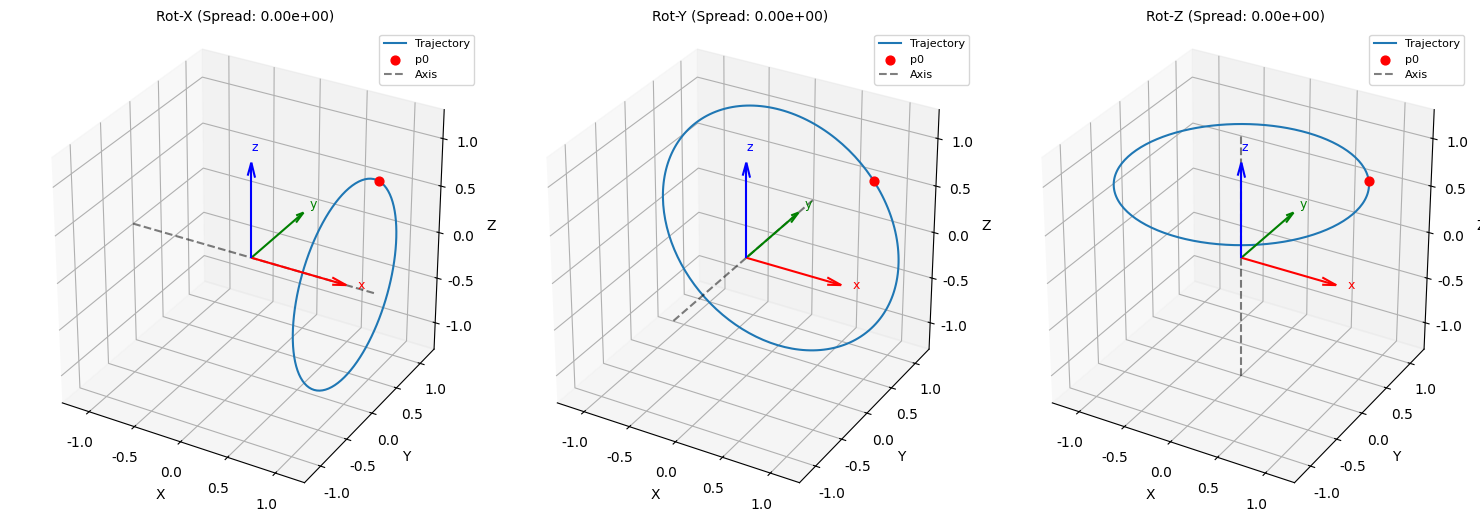

=== Conserved Component Spread ===
Rot-X: 0.000000e+00
Rot-Y: 0.000000e+00
Rot-Z: 0.000000e+00


In [4]:
p0 = np.array([1.0, 0.6, 0.8])
angles = np.linspace(0.0, 2.0 * np.pi, 200)

info = []     # (Name, Spread of conserved component)

fig = plt.figure(figsize=(15, 5))

axes_config = [
    ("Rot-X", rot_x, np.array([1.0, 0.0, 0.0]), 0),  # x-component preserved
    ("Rot-Y", rot_y, np.array([0.0, 1.0, 0.0]), 1),  # y-component preserved
    ("Rot-Z", rot_z, np.array([0.0, 0.0, 1.0]), 2),  # z-component preserved
]

for k, (name, maker, axis_vec, keep) in enumerate(axes_config):

    # 1. Trajectory calculation
    traj = np.array([
        maker(theta) @ p0
        for theta in angles
    ])

    # 2. Spread calculation of preserved component
    spread = np.max(traj[:, keep]) - np.min(traj[:, keep])

    info.append((name, spread))

    # 3. Create 3D subplot
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")

    # 4. Plot trajectory
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        traj[:, 2],
        label="Trajectory"
    )

    # Start point
    ax.scatter(
        p0[0],
        p0[1],
        p0[2],
        s=40,
        color="red",
        label="p0"
    )

    # 5. Rotation axis dashed line
    axis_line = np.outer(
        np.linspace(-1.3, 1.3, 10),
        axis_vec
    )

    ax.plot(
        axis_line[:, 0],
        axis_line[:, 1],
        axis_line[:, 2],
        "--",
        alpha=0.5,
        color="black",
        label="Axis"
    )

    # 6. Axis setup and title in English
    setup_axes(
        ax,
        f"{name} (Spread: {spread:.2e})"
    )

    draw_frame(ax)

    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print spread results
print("=== Conserved Component Spread ===")

for name, spread in info:
    print(f"{name}: {spread:.6e}")

In [5]:
# --- 검증 ---
ok = True
for name, spread in info:
    ok &= check(name + " : 보존 성분 변화폭 {:.2e} < 1e-12".format(spread), spread < 1e-12)

# 궤적 위 모든 점이 원점에서 같은 거리(회전은 길이 보존)
traj = np.array([rot_z(t) @ p0 for t in angles])
radii = np.linalg.norm(traj, axis=1)
ok &= check("회전 궤적의 모든 점이 원점에서 등거리",
            np.allclose(radii, np.linalg.norm(p0)))
print("\n2-2 전체 통과:", ok)

[PASS] Rot-X : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] Rot-Y : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] Rot-Z : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] 회전 궤적의 모든 점이 원점에서 등거리

2-2 전체 통과: True


## 2-3. 합성 순서가 다르면 결과가 다르다

행렬 곱은 교환법칙이 성립하지 않습니다: $R_y R_z \neq R_z R_y$.

표기 약속: $R_y R_z \mathbf{p}$ 는 "**$R_z$ 를 먼저**, 그다음 $R_y$" 라는 뜻입니다
(오른쪽 것이 먼저 적용됩니다).

**할 일**

- y축 90도와 z축 90도를 두 순서로 합성해 결과 행렬 A, B 를 만들고 차이를 출력하세요.
- 같은 초기 자세(단위행렬)가 두 순서로 어떻게 다르게 끝나는지
  **초기 / 순서① / 순서②** 3분할 3D 그림으로 나란히 그리세요.
- 왜 물리적으로 당연한 결과인지 아래에 적으세요.

### 순서가 결과를 바꾸는 이유

- `___`

In [6]:
ang = np.deg2rad(90.0)

# TODO: A = rot_y(ang) @ rot_z(ang), B = rot_z(ang) @ rot_y(ang) 를 만들고
#       두 행렬과 차이(최대 절댓값)를 출력하세요.

A = rot_y(ang) @ rot_z(ang)

B = rot_z(ang) @ rot_y(ang)

print(" z먼저 : \n", A)
print("\ny먼저 : \n", A)
print("\n 차이의 절대값 : ", np.max(np.abs(A-B)))


# TODO: (1,0,0) 이 두 순서에서 각각 어디로 가는지도 출력하세요.

ori = np.array([1,0,0])

print(" 원본 위치 : " ,ori)

print("\n z->y 순서 90도 씩 : " ,A@ori)
print("\n y->z 순서 90도 씩 : " ,B@ori)




 z먼저 : 
 [[ 0. -0.  1.]
 [ 1.  0.  0.]
 [-0.  1.  0.]]

y먼저 : 
 [[ 0. -0.  1.]
 [ 1.  0.  0.]
 [-0.  1.  0.]]

 차이의 절대값 :  1.0
 원본 위치 :  [1 0 0]

 z->y 순서 90도 씩 :  [ 0.  1. -0.]

 y->z 순서 90도 씩 :  [ 0.  0. -1.]


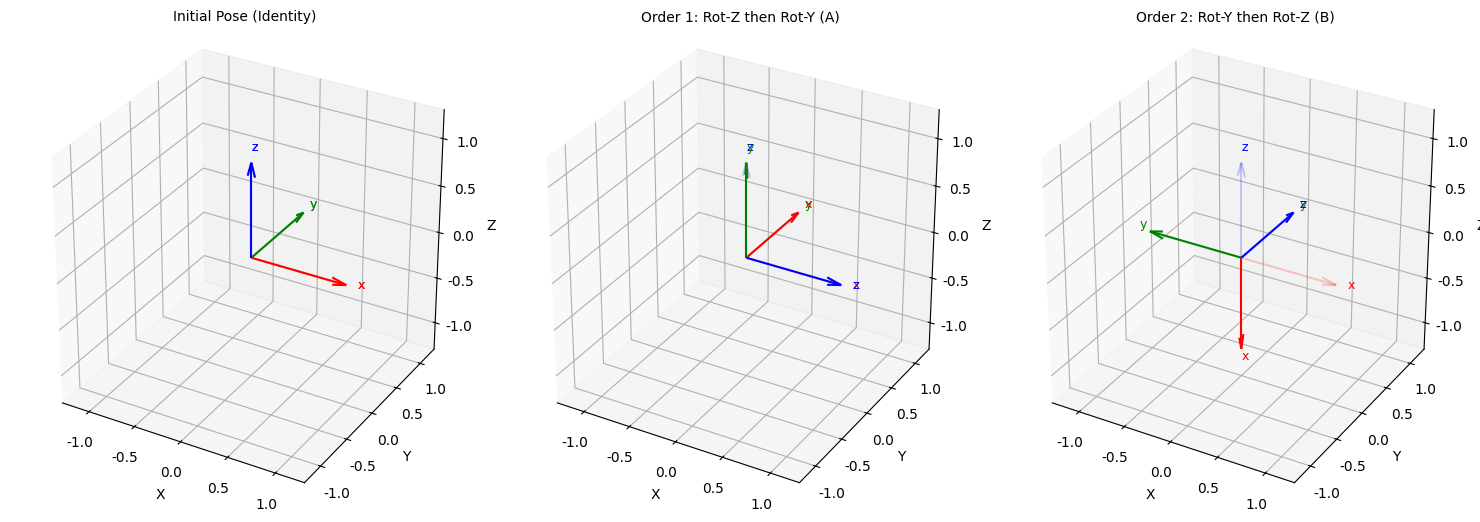

In [7]:
# TODO: 3분할 3D 그림 (초기 자세 / 순서① / 순서②) 을 그리세요.
#       draw_frame(ax, np.eye(3), alpha=0.2) 로 기준 좌표계를 흐리게 깔면 비교가 쉽습니다.

fig = plt.figure(figsize=(15,5))
frame = [
    ("Initial Pose (Identity)", np.eye(3)),
    ("Order 1: Rot-Z then Rot-Y (A)", A),
    ("Order 2: Rot-Y then Rot-Z (B)", B)
]

for k, (title, R ) in enumerate(frame):
        ax = fig.add_subplot(1,3,k+1,projection="3d")
        draw_frame(ax,np.eye(3), alpha=0.2)
        draw_frame(ax, R,alpha=1.0)
        setup_axes(ax,title)

plt.tight_layout()
plt.show()

In [8]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 두 합성 결과 행렬이 다른가
#   - 같은 축끼리는 순서를 바꿔도 같은가 (교환 가능)
#   - 각도가 0 이면 순서가 무의미한가
#   - 두 결과 모두 회전행렬인가 (det = 1)
#   - A 와 B 가 (1,0,0) 을 서로 다른 곳으로 보내는가
# --- 검증 ---
ok = check("두 합성 결과 행렬이 다르다", not np.allclose(A, B))
ok &= check("같은 축끼리는 순서를 바꿔도 같다 (교환 가능)",
            np.allclose(rot_z(0.3) @ rot_z(0.9), rot_z(0.9) @ rot_z(0.3)))
ok &= check("각도가 0 이면 순서가 무의미", np.allclose(rot_y(0.0) @ rot_z(0.5), rot_z(0.5) @ rot_y(0.0)))
ok &= check("두 결과 모두 회전행렬 (det = 1)",
            np.isclose(det(A), 1.0) and np.isclose(det(B), 1.0))
ok &= check("A 와 B 는 서로 다른 축으로 (1,0,0) 을 보낸다",
            not np.allclose(A @ a, B @ a))
print("\n2-3 전체 통과:", ok)

[PASS] 두 합성 결과 행렬이 다르다
[PASS] 같은 축끼리는 순서를 바꿔도 같다 (교환 가능)
[PASS] 각도가 0 이면 순서가 무의미
[PASS] 두 결과 모두 회전행렬 (det = 1)
[PASS] A 와 B 는 서로 다른 축으로 (1,0,0) 을 보낸다

2-3 전체 통과: True


## 2-4. 행렬식이 1 이어야 하는 이유 — 회전 vs 반사

직교행렬($R^{\mathsf{T}}R=I$)의 행렬식은 $\pm 1$ 뿐입니다.
$\det(R^{\mathsf{T}}R)=\det(R)^2=\det(I)=1$ 이기 때문입니다.

그렇다면 $\det = -1$ 인 직교행렬은 무엇일까요?
대각성분이 $(1,1,-1)$ 인 행렬을 놓고 다음을 직접 확인해 보세요.

- 직교성($S^{\mathsf{T}}S=I$)은 만족하는가
- 행렬식은 얼마인가
- $\mathbf{x}' \times \mathbf{y}' = \mathbf{z}'$ (오른손 규칙)이 유지되는가

세 질문의 답을 모으면 "왜 직교만으로는 부족하고 $\det=+1$ 까지 요구하는가" 가 나옵니다.
로봇 자세에 $\det=-1$ 행렬이 들어가면 실제로 무슨 일이 벌어질지도 함께 적으세요.

### 행렬식이 1 이어야 하는 이유

- 회전 행렬 세 개의 행렬식: `___` / 반사 행렬의 행렬식: `___`
- 차이의 의미: `___`
- 로봇에서의 영향: `___`

In [9]:
S = np.diag([1.0, 1.0, -1.0]) 
# z 를 뒤집는 반사 행렬


# TODO: 회전 행렬 3개와 반사 행렬 S 에 대해
#       det(직접 구현), 직교 오차 |M.T @ M - I| 를 표로 출력하세요.
mat=[
    ("rot_x",rot_x(np.pi/4)),
    ("rot_y",rot_y(np.pi/4)),
    ("rot_z",rot_z(np.pi/4)),
    ("reflection ", S)
]
for name , M in mat:
    DET = det(M)

    I = np.eye(3)
    orth_er = norm((M.T @ M-I).ravel())


    print("name : ",name)
    print("det : ",DET)
    print("직교성 오차 : ",orth_er)

        
# TODO: 각 행렬에 대해 x' x y' == z' 인지도 함께 출력하세요.

    x = M @ np.array([1,0,0])
    y = M @ np.array([0,1,0])
    z = M @ np.array([0,0,1])

    print("x' × y' == z' : ", np.allclose(cross(x,y),z))
    print()


name :  rot_x
det :  1.0
직교성 오차 :  1.434936932798653e-17
x' × y' == z' :  True

name :  rot_y
det :  1.0
직교성 오차 :  1.434936932798653e-17
x' × y' == z' :  True

name :  rot_z
det :  1.0
직교성 오차 :  1.434936932798653e-17
x' × y' == z' :  True

name :  reflection 
det :  -1.0
직교성 오차 :  0.0
x' × y' == z' :  False



In [10]:
# --- 검증 ---
ok = check("세 회전 행렬의 행렬식이 모두 1",
           all(np.isclose(det(m(t)), 1.0) for m, t in [(rot_x, 0.7), (rot_y, 1.2), (rot_z, -0.4)]))
ok &= check("반사 행렬의 행렬식은 -1", np.isclose(det(S), -1.0))
ok &= check("반사 행렬도 직교이긴 하다", np.allclose(S.T @ S, np.eye(3)))
ok &= check("회전은 오른손 규칙 보존 (x' x y' == z')",
            np.allclose(np.cross(rot_y(1.2)[:, 0], rot_y(1.2)[:, 1]), rot_y(1.2)[:, 2]))
ok &= check("반사는 오른손 규칙을 깬다",
            not np.allclose(np.cross(S[:, 0], S[:, 1]), S[:, 2]))
ok &= check("무작위 회전 100개의 det 가 모두 1",
            all(np.isclose(det(rot_z(t1) @ rot_y(t2) @ rot_x(t3)), 1.0)
                for t1, t2, t3 in rng.uniform(-np.pi, np.pi, (100, 3))))
print("\n2-4 전체 통과:", ok)

[PASS] 세 회전 행렬의 행렬식이 모두 1
[PASS] 반사 행렬의 행렬식은 -1
[PASS] 반사 행렬도 직교이긴 하다
[PASS] 회전은 오른손 규칙 보존 (x' x y' == z')
[PASS] 반사는 오른손 규칙을 깬다
[PASS] 무작위 회전 100개의 det 가 모두 1

2-4 전체 통과: True


## 2-5. 로드리게스 공식 — `skew` 로 임의 축 회전

단위 축 $\mathbf{k}$ 를 중심으로 $\theta$ 만큼 도는 회전은

$$R = I + \sin\theta\,[\mathbf{k}]_\times + (1-\cos\theta)\,[\mathbf{k}]_\times^2$$

로 쓸 수 있습니다. 문제 1 에서 만든 `skew` 가 그대로 들어갑니다.
축을 $\mathbf{k}=(0,0,1)$ 로 두면 `rot_z` 와 정확히 같아야 합니다.

**할 일** — `src/rotation.py` 의 `rodrigues` 를 구현하고,
z축·임의 축 두 경우를 확인하세요. 축이 회전 후에도 그대로인지도 봅니다.

In [13]:
theta = np.deg2rad(37.0)

# TODO: rodrigues([0,0,1], theta) 와 rot_z(theta) 를 비교 출력하세요.

point = np.array([2,3,4])

sp = rot_z(theta) @ point

#z축
axis = np.array([0,0,1])

R = rodrigues([0, 0, 1], theta)

print("Rodrigues:")
print(R)

print("\nrot_z:")
print(rot_z(theta))


print("\n TODO: 임의 축 k = (1, 2, -0.5) 로도 만들어 보고, R @ k 가 k 그대로인지 확인하세요.")

#임의 축 k
k = np.array([1,2,-0.5])

Rmat = rodrigues_matrix(k, theta)

print(" R @ k = ", Rmat @ k)

print(" k = ", k)


print("\n TODO: skew 로 공식을 손으로 조립한 결과와 rodrigues 결과가 같은지 확인하세요.")


Kunit = k/norm(k)
sK = skew(Kunit)
I = np.eye(3)

R_manual= ( 
    I + np.sin(theta)*sK + (1-np.cos(theta))*(sK@sK)
) 


print("\n=== skew로 직접 조립한 결과 ===")
print(R_manual)

print("\n=== rodrigues_matrix 결과 ===")
print(Rmat)

check(
    "직접 조립한 Rodrigues와 rodrigues_matrix가 같다",
    np.allclose(R_manual, Rmat)
)

Rodrigues:
[[ 0.798636 -0.601815  0.      ]
 [ 0.601815  0.798636  0.      ]
 [ 0.        0.        1.      ]]

rot_z:
[[ 0.798636 -0.601815  0.      ]
 [ 0.601815  0.798636  0.      ]
 [ 0.        0.        1.      ]]

 TODO: 임의 축 k = (1, 2, -0.5) 로도 만들어 보고, R @ k 가 k 그대로인지 확인하세요.
 R @ k =  [ 1.   2.  -0.5]
 k =  [ 1.   2.  -0.5]

 TODO: skew 로 공식을 손으로 조립한 결과와 rodrigues 결과가 같은지 확인하세요.

=== skew로 직접 조립한 결과 ===
[[ 0.836991  0.208037  0.50613 ]
 [-0.054617  0.952056 -0.301009]
 [-0.544485  0.224298  0.808224]]

=== rodrigues_matrix 결과 ===
[[ 0.836991  0.208037  0.50613 ]
 [-0.054617  0.952056 -0.301009]
 [-0.544485  0.224298  0.808224]]
[PASS] 직접 조립한 Rodrigues와 rodrigues_matrix가 같다


True

In [15]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - rodrigues(z축) == rot_z, rodrigues(x축) == rot_x, rodrigues(y축) == rot_y
#   - 임의 축 결과가 회전행렬인가 (det = 1, 직교)
#   - 회전축은 변하지 않는가 (R k == k)
#   - 정규화되지 않은 축을 줘도 같은 결과인가
#   - 무작위 축 50개가 모두 회전행렬인가

# --- 검증 ---
ok = check("rodrigues(z축) == rot_z", np.allclose(R, rot_z(theta)))
ok &= check("rodrigues(x축) == rot_x", np.allclose(rodrigues([1, 0, 0], theta), rot_x(theta)))
ok &= check("rodrigues(y축) == rot_y", np.allclose(rodrigues([0, 1, 0], theta), rot_y(theta)))
ok &= check("임의 축 결과가 회전행렬 (det = 1)", np.isclose(det(Rmat), 1.0))
ok &= check("임의 축 결과가 직교", np.allclose(Rmat.T @ Rmat, np.eye(3)))
ok &= check("회전축은 변하지 않는다 (R k == k)", np.allclose(Rmat @ k, k))
ok &= check("정규화 안 된 축을 줘도 같은 결과",
            np.allclose(rodrigues([1.0, 2.0, -0.5], theta), Rmat))
ok &= check("무작위 축 50개 모두 회전행렬",
            all(np.isclose(det(rodrigues(ax, t)), 1.0)
                for ax, t in zip(rng.standard_normal((50, 3)), rng.uniform(-np.pi, np.pi, 50))))
print("\n2-5 전체 통과:", ok)

[PASS] rodrigues(z축) == rot_z
[PASS] rodrigues(x축) == rot_x
[PASS] rodrigues(y축) == rot_y
[PASS] 임의 축 결과가 회전행렬 (det = 1)
[PASS] 임의 축 결과가 직교
[PASS] 회전축은 변하지 않는다 (R k == k)
[PASS] 정규화 안 된 축을 줘도 같은 결과
[PASS] 무작위 축 50개 모두 회전행렬

2-5 전체 통과: True


## 답안 템플릿 정리

In [16]:
summary = """
1. rot_z(90도) 로 변환한 (1,0,0): [0.0, 1.0, 0.0]   (기대값 [0.0, 1.0, 0.0], 일치 True)

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: 약 0, y: 약 0, z: 약 0

3. 합성 순서 비교 — 두 결과 행렬이 다른가: True
   - 최대 성분 차이: 1.0 / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: 3차원 회전행렬은 일반적으로 교환법칙이 성립하지 않기 때문에 회전 순서에 따라 최종 자세가 달라진다.

4. 세 회전 행렬의 행렬식: 1 / 반사 행렬의 행렬식: -1
   - 차이의 의미: 회전 행렬은 공간의 방향을 보존하지만, 반사 행렬은 좌표계의 방향을 뒤집는다. 따라서 직교성만으로는 실제 회전과 반사를 구분할 수 없고 det=+1 조건이 필요하다.

5. 로드리게스 구현과 rot_z 일치: True
   - 임의 축에서도 det=1, 직교, R k = k 확인: True
"""
print(summary)


1. rot_z(90도) 로 변환한 (1,0,0): [0.0, 1.0, 0.0]   (기대값 [0.0, 1.0, 0.0], 일치 True)

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: 약 0, y: 약 0, z: 약 0

3. 합성 순서 비교 — 두 결과 행렬이 다른가: True
   - 최대 성분 차이: 1.0 / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: 3차원 회전행렬은 일반적으로 교환법칙이 성립하지 않기 때문에 회전 순서에 따라 최종 자세가 달라진다.

4. 세 회전 행렬의 행렬식: 1 / 반사 행렬의 행렬식: -1
   - 차이의 의미: 회전 행렬은 공간의 방향을 보존하지만, 반사 행렬은 좌표계의 방향을 뒤집는다. 따라서 직교성만으로는 실제 회전과 반사를 구분할 수 없고 det=+1 조건이 필요하다.

5. 로드리게스 구현과 rot_z 일치: True
   - 임의 축에서도 det=1, 직교, R k = k 확인: True

